In [1]:
import pandas as pd
df_comp = pd.read_csv('computation-time.csv')
df_comm = pd.read_csv('communication-time.csv')

In [2]:
df_comp

,cluster,application_name,packages.dependencies.hip.version,Avg time/rank (exc)
0,tioga,amg2023,7.2.0,3.231351
1,frontier,amg2023,7.2.0,3.180802
2,tioga,amg2023,7.2.0,3.289163
3,frontier,amg2023,6.4.2,2.695746
4,tioga,amg2023,7.2.0,3.220476
...,...,...,...,...
60,frontier,laghos,7.2.0,332.658722
61,frontier,laghos,7.2.0,332.005263
62,frontier,laghos,7.2.0,332.848519
63,frontier,laghos,6.4.2,313.018487


In [3]:
df_comm

,cluster,application_name,packages.dependencies.hip.version,Avg time/rank (exc)
0,tioga,amg2023,7.2.0,0.470855
1,frontier,amg2023,7.2.0,0.567146
2,tioga,amg2023,7.2.0,0.599252
3,frontier,amg2023,6.4.2,0.333660
4,tioga,amg2023,7.2.0,0.315372
...,...,...,...,...
60,frontier,laghos,7.2.0,56.843986
61,frontier,laghos,7.2.0,52.461479
62,frontier,laghos,7.2.0,50.857336
63,frontier,laghos,6.4.2,48.648300


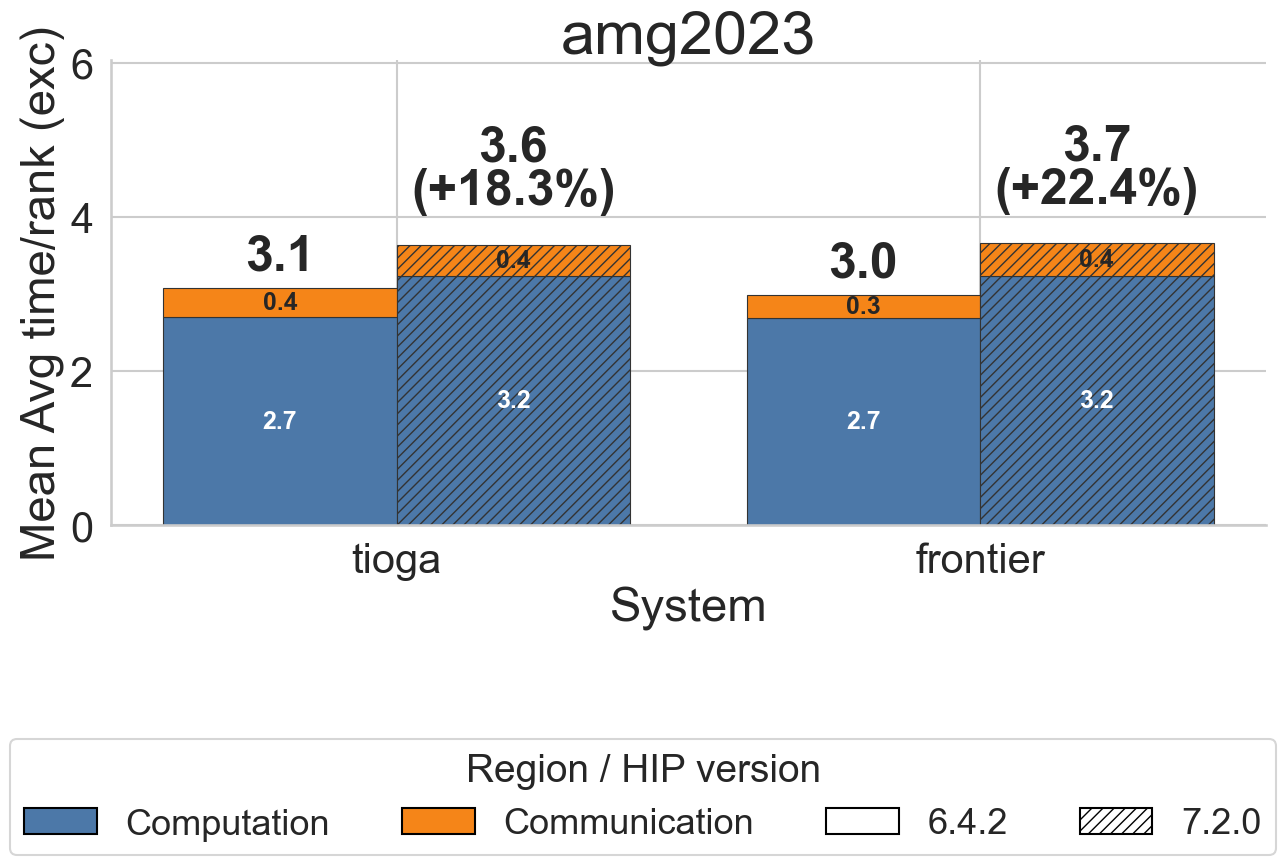

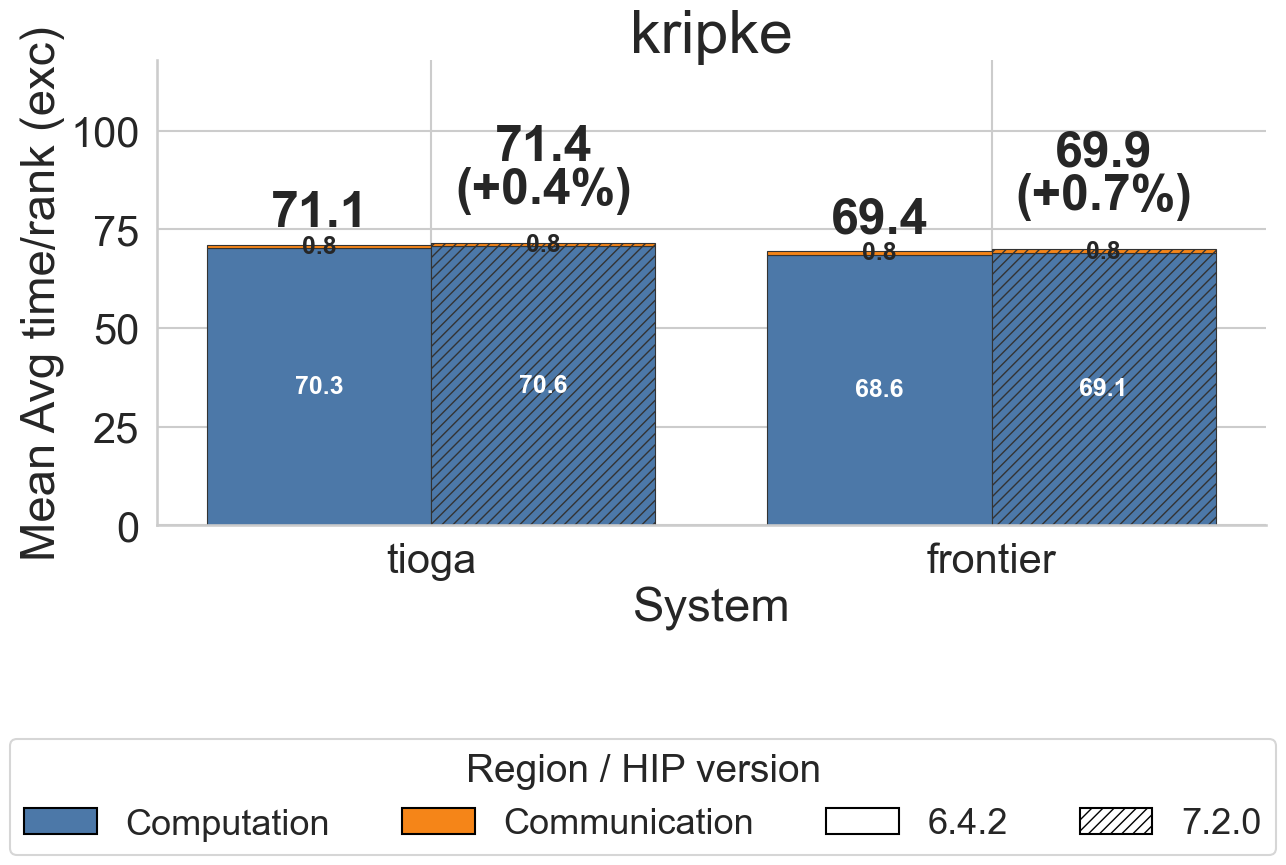

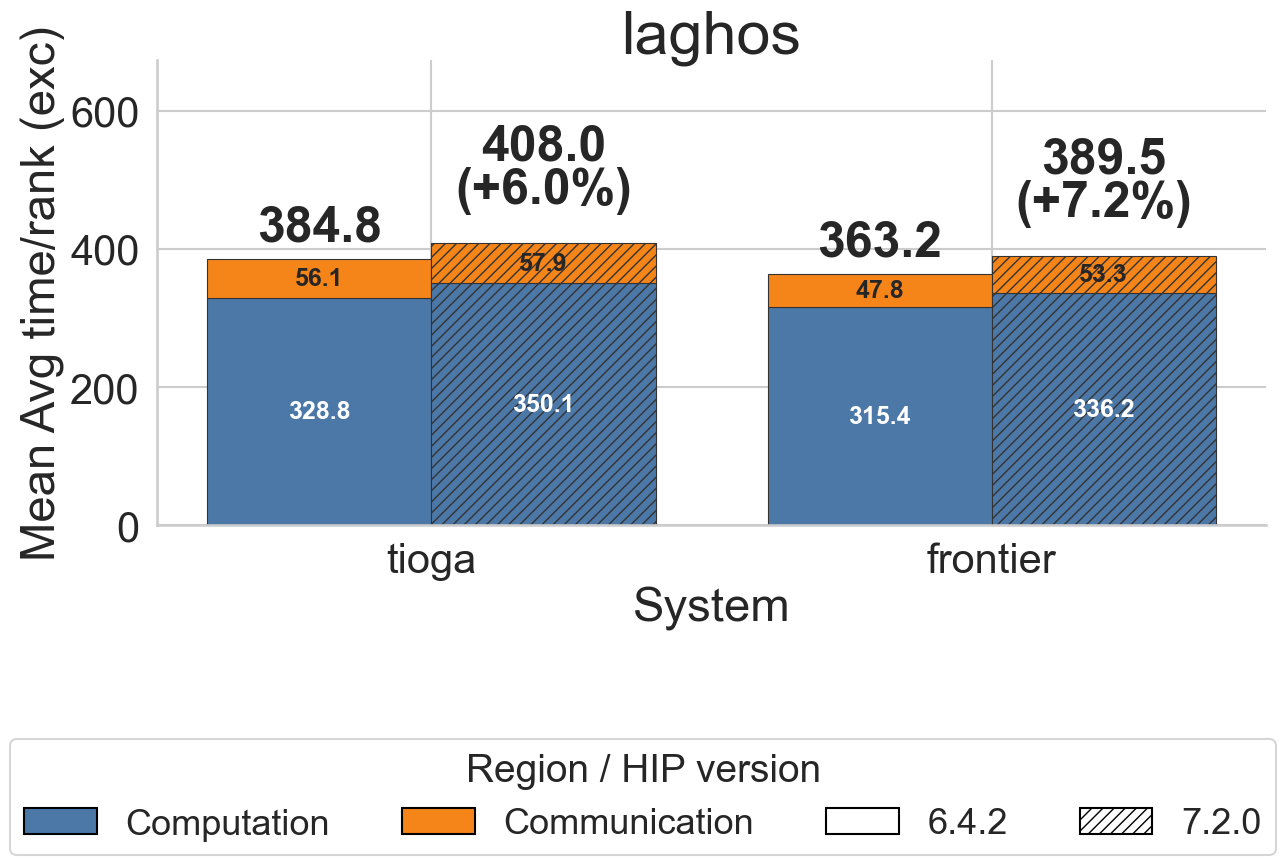

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

value_col = 'Avg time/rank (exc)'
summary_stat = 'mean'  # use 'mean' for average
version_col = 'packages.dependencies.hip.version'
group_cols = ['cluster', 'application_name', version_col]

bar_df = (
    pd.concat(
        [df_comp.assign(region='Computation'), df_comm.assign(region='Communication')],
        ignore_index=True,
    )
    .groupby(group_cols + ['region'])[value_col]
    .agg(summary_stat)
    .unstack(fill_value=0)
    .reset_index()
)
for component in ['Computation', 'Communication']:
    if component not in bar_df:
        bar_df[component] = 0
bar_df['total'] = bar_df['Computation'] + bar_df['Communication']
bar_df[version_col] = bar_df[version_col].astype(str)

version_order = sorted(bar_df[version_col].astype(str).unique())
app_order = sorted(bar_df['application_name'].unique())
preferred_clusters = ['tioga', 'frontier']
cluster_order = [c for c in preferred_clusters if c in set(bar_df['cluster'])]
cluster_order += [c for c in sorted(bar_df['cluster'].unique()) if c not in cluster_order]

sns.set_theme(style='whitegrid', context='talk')
title_size = 44
axis_label_size = 34
tick_label_size = 30
legend_title_size = 28
legend_label_size = 26
total_label_size = 36
region_label_size = 18
region_colors = {'Computation': '#4C78A8', 'Communication': '#F58518'}
hatches = ['', '///', 'xxx', '...']
version_hatches = {version: hatches[i % len(hatches)] for i, version in enumerate(version_order)}
region_handles = [
    Patch(facecolor=color, edgecolor='black', label=region)
    for region, color in region_colors.items()
]
version_handles = [
    Patch(facecolor='white', edgecolor='black', hatch=version_hatches[version], label=version)
    for version in version_order
]

x = np.arange(len(cluster_order))
bar_width = 0.8 / len(version_order)
offsets = (np.arange(len(version_order)) - (len(version_order) - 1) / 2) * bar_width

for app in app_order:
    app_df = bar_df[bar_df['application_name'] == app]
    baseline_totals = (
        app_df[app_df[version_col] == version_order[0]]
        .set_index('cluster')
        .reindex(cluster_order, fill_value=0)['total']
    )
    fig, ax = plt.subplots(figsize=(13, 9))
    total_label_offset = app_df['total'].max() * 0.03

    for version_idx, (offset, version) in enumerate(zip(offsets, version_order)):
        version_df = app_df[app_df[version_col] == version].set_index('cluster')
        version_df = version_df.reindex(cluster_order, fill_value=0)
        xpos = x + offset

        comp_bars = ax.bar(
            xpos,
            version_df['Computation'],
            bar_width,
            color=region_colors['Computation'],
            edgecolor='0.2',
            linewidth=0.8,
            hatch=version_hatches[version],
        )
        comm_bars = ax.bar(
            xpos,
            version_df['Communication'],
            bar_width,
            bottom=version_df['Computation'],
            color=region_colors['Communication'],
            edgecolor='0.2',
            linewidth=0.8,
            hatch=version_hatches[version],
        )

        for bars, values, color in [
            (comp_bars, version_df['Computation'], 'white'),
            (comm_bars, version_df['Communication'], '0.15'),
        ]:
            for bar, value in zip(bars, values):
                if value == 0:
                    continue
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{value:.1f}',
                    ha='center',
                    va='center',
                    color=color,
                    fontsize=region_label_size,
                    fontweight='bold',
                )

        for bar, total, baseline_total in zip(comp_bars, version_df['total'], baseline_totals):
            if total == 0:
                continue
            total_label = f'{total:.1f}'
            if version_idx > 0 and baseline_total != 0:
                pct_change = (total - baseline_total) / baseline_total * 100
                total_label += f'\n({pct_change:+.1f}%)'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                total + total_label_offset * (1 + version_idx * 2.5),
                total_label,
                ha='center',
                va='bottom',
                rotation=0,
                color='0.15',
                fontsize=total_label_size,
                fontweight='bold',
                linespacing=0.9,
            )

    fig.legend(
        handles=region_handles + version_handles,
        title='Region / HIP version',
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=len(region_handles) + len(version_handles),
        fontsize=legend_label_size,
        title_fontsize=legend_title_size,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(cluster_order)
    ax.set_xlabel('System', fontsize=axis_label_size)
    ax.set_ylabel(f'{summary_stat.title()} {value_col}', fontsize=axis_label_size)
    ax.set_title(app, fontsize=title_size)
    ax.tick_params(axis='both', labelsize=tick_label_size)
    ax.set_ylim(0, app_df['total'].max() * 1.65)
    sns.despine(ax=ax)
    fig.tight_layout(rect=[0, 0.25, 1, 1])
    safe_app = str(app).replace(' ', '_').replace('/', '-')
    fig.savefig(f'stacked_barchart_{safe_app}.png', dpi=300, bbox_inches='tight')
    plt.show()